In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import zarr
import os
import sys
import glob

from pathlib import Path

sys.path.append(os.path.abspath(".."))

plt.style.use('../libs/my_style.mplstyle')

cargo_diameter = 5.00

mypass = Path('/mnt/NAS-Ebanaru/sasaki/MTSingleBeads')
mypass = Path('/Volumes/data/Sasaki/MTsingleBeads')
subdir = "beads5um"
output = f'global_order_boxplot{cargo_diameter}.pdf'

input_dir = mypass / subdir
op_data = []

labels = []

i = 0

# データの読み込み
for exp_subpath in sorted(glob.glob(str(input_dir/ "*" / "*"))):
    exp_subpath = Path(exp_subpath)
    target_path =  exp_subpath / "MTs_order_parameter.zarr"
    
    if target_path.exists():
        try:
            op_zarr = zarr.open(str(target_path), mode='r')
            op = op_zarr[:]
            
            # NaNなどの無効な値を除外して1次元配列にする
            op = np.array(op).flatten()
            op = op[~np.isnan(op)]
            op_data.append(op)
            
            # ラベルに実験のサブパスを使用
            labels.append(exp_subpath.name)
            
            num = len(op)
            op_mean = np.mean(op) if num > 0 else np.nan
            op_sem = np.std(op, ddof=1)/np.sqrt(num) if num > 1 else 0
            print(f"exp{i}: Mean = {op_mean:.4f}, SEM = {op_sem:.4f}, N = {num}")
            print(target_path)

            i+=1
            
        except Exception as e:
            print(f"Error loading {target_path}: {e}")
    #else:
        #print(f"Warning: {target_path} does not exist.")

exp0: Mean = 0.9656, SEM = 0.0014, N = 173
/Volumes/data/Sasaki/MTsingleBeads/beads5um/20260715/beads5um/MTs_order_parameter.zarr
exp1: Mean = 0.9361, SEM = 0.0023, N = 202
/Volumes/data/Sasaki/MTsingleBeads/beads5um/20260715/beads5um001/MTs_order_parameter.zarr
exp2: Mean = 0.8583, SEM = 0.0035, N = 1801
/Volumes/data/Sasaki/MTsingleBeads/beads5um/20260715/beads5um002/MTs_order_parameter.zarr
exp3: Mean = 0.7366, SEM = 0.0099, N = 1801
/Volumes/data/Sasaki/MTsingleBeads/beads5um/20260715/beads5um003/MTs_order_parameter.zarr


Saved boxplot to global_order_boxplot5.0.pdf


/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_49581/1079062219.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(op_data, labels=labels, patch_artist=True)


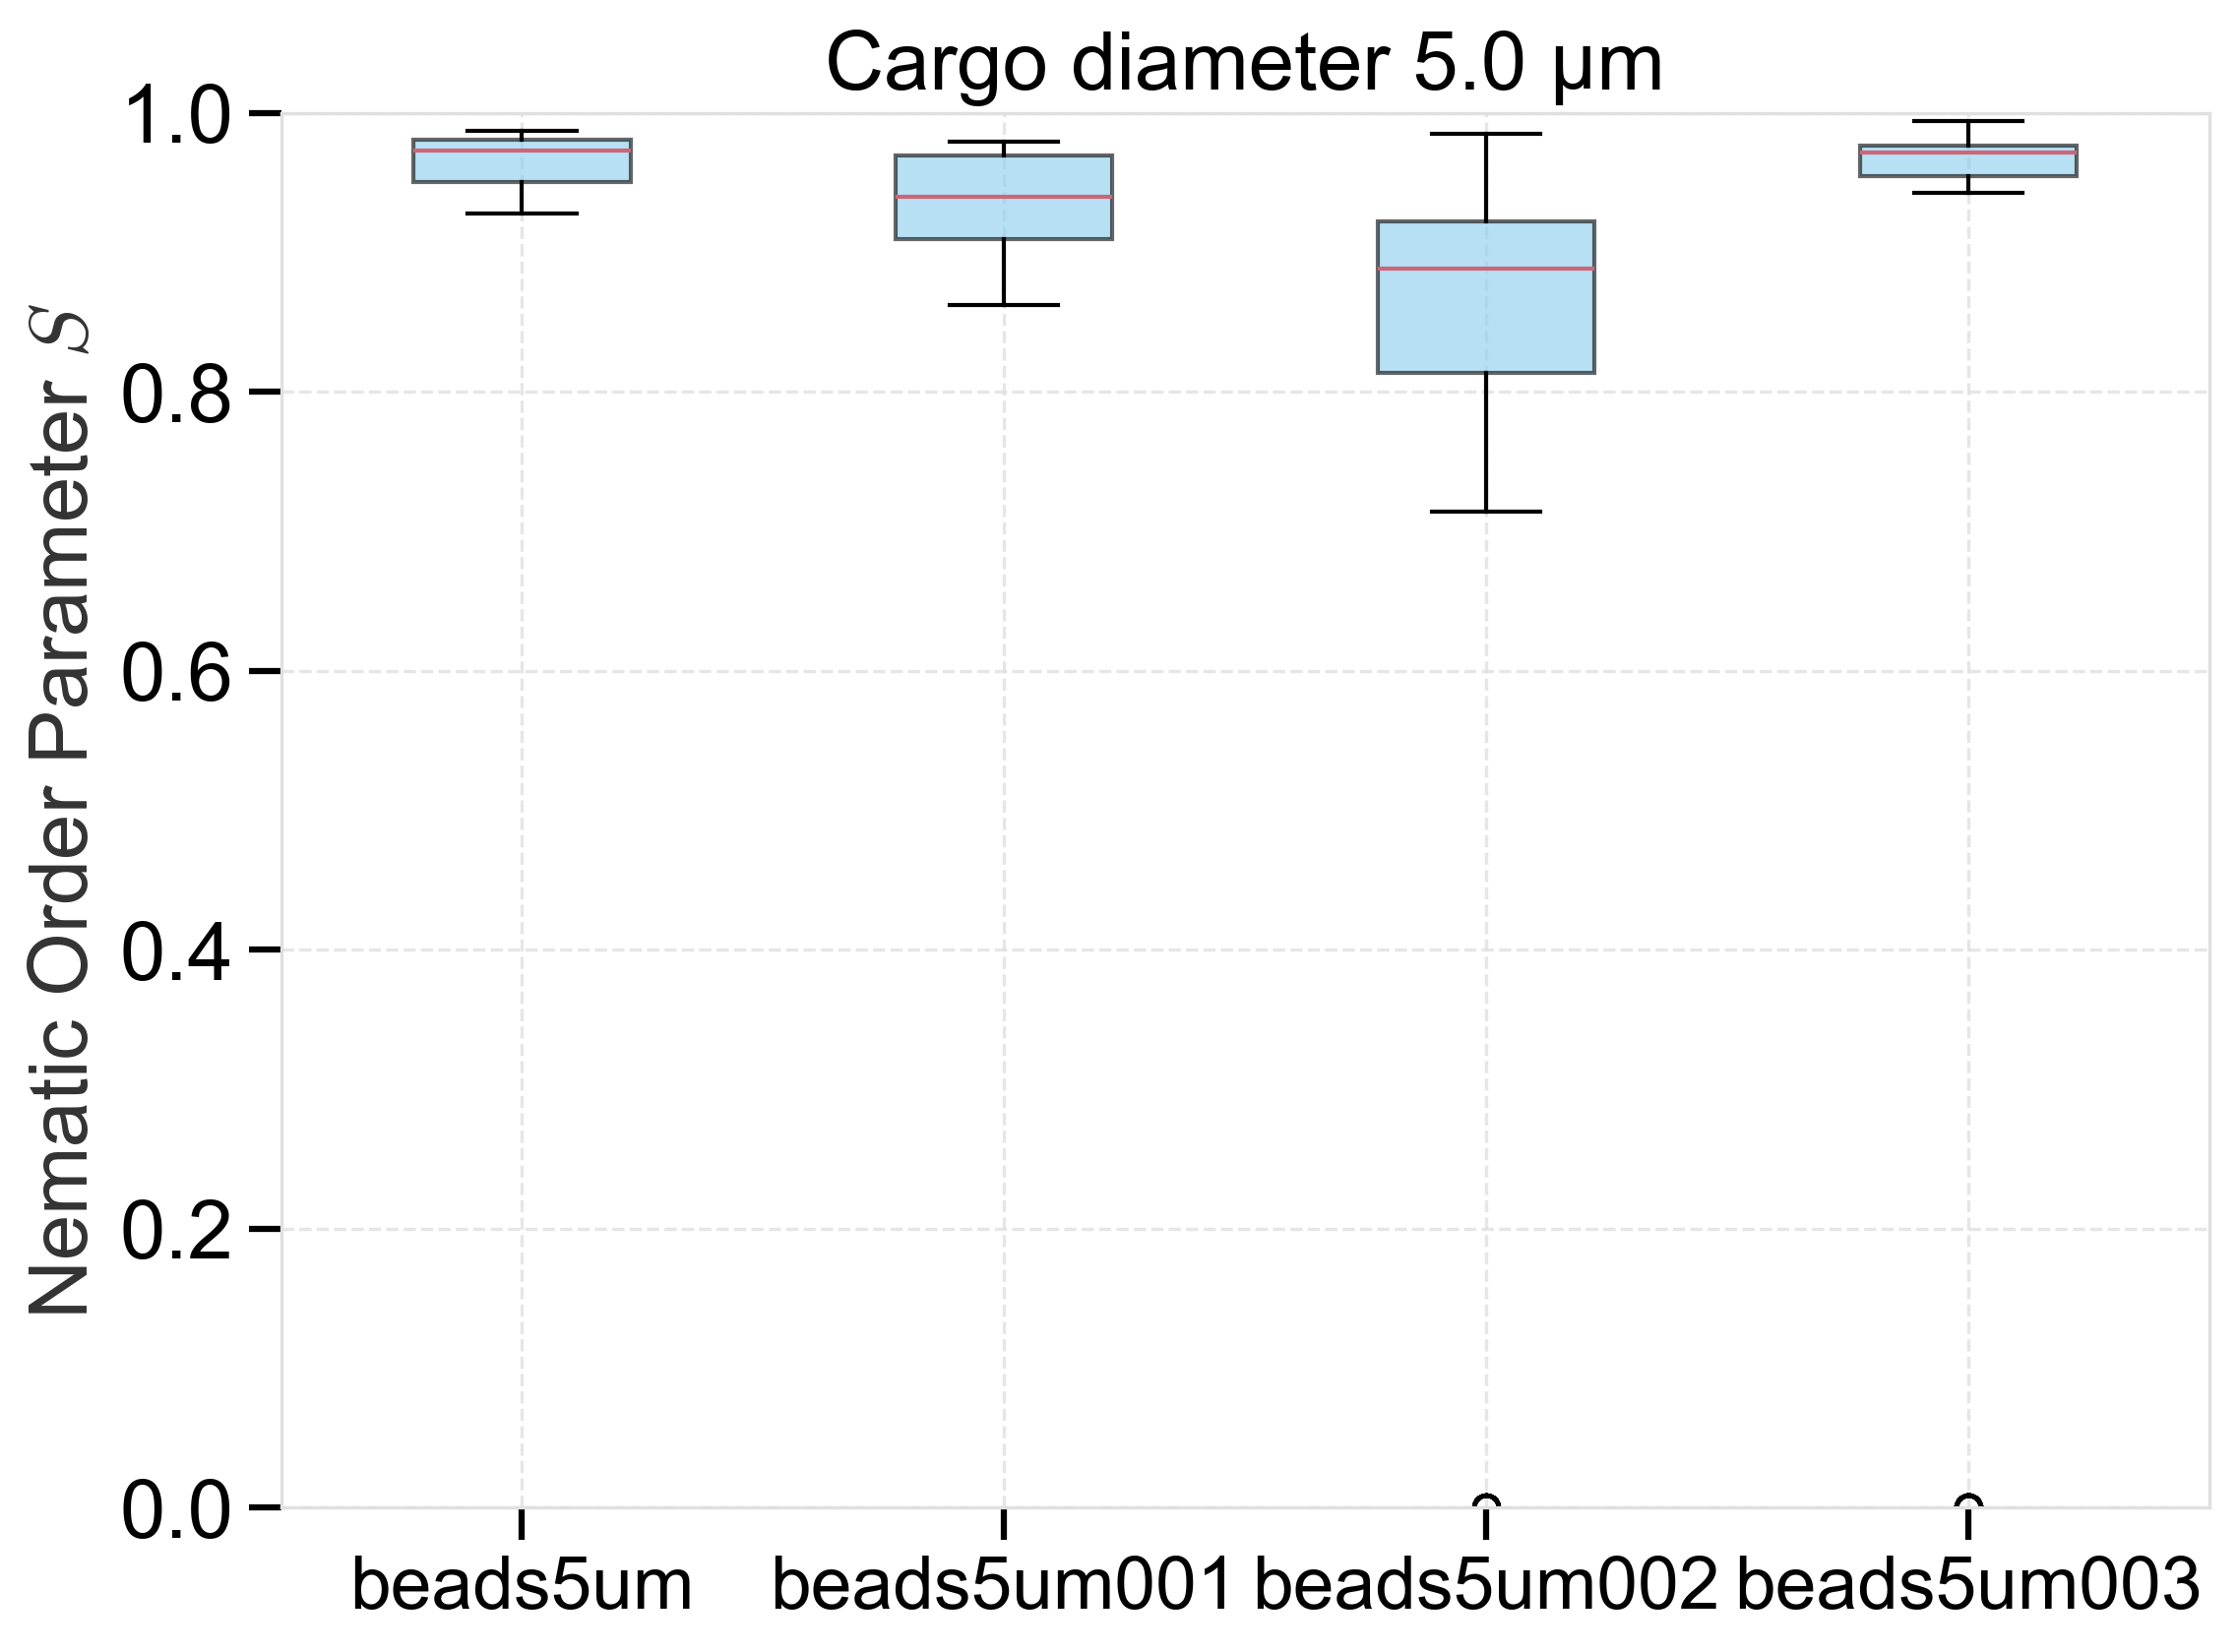

In [12]:
# 箱ひげ図の作成
if op_data:
    fig, ax = plt.subplots()
    
    # ボックスプロットを描画
    bp = ax.boxplot(op_data, labels=labels, patch_artist=True)
    
    # 見やすくするために色を付ける（オプション）
    for box in bp['boxes']:
        box.set(facecolor='#88CCEE', alpha=0.6)

    #bp['boxes'][4].set(facecolor='#FF6666', alpha=0.6)

    ax.set_ylabel("Nematic Order Parameter $S$")
    ax.set_title(f"Cargo diameter {cargo_diameter} \u03bcm")
    ax.set_ylim(0.0, 1.0)
    plt.xticks(rotation=0, ha='center', fontsize=18)
    plt.tight_layout()
    
    # 画像の保存
    plt.savefig(mypass/"figure"/output, dpi=300)
    print(f"Saved boxplot to {output}")
else:
    print("No valid data available to plot.")

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import zarr
import os
import sys
import glob

from pathlib import Path

sys.path.append(os.path.abspath(".."))

plt.style.use('../libs/my_style.mplstyle')

#mypass = Path('/mnt/NAS-Ebanaru/sasaki/MTSingleBeads')
mypass = Path('/Volumes/data/Sasaki/MTsingleBeads/control')

input_dir = mypass

def load(input_dir, folder):
    op_data = []

    # データの読み込み
    for exp_subpath in sorted(glob.glob(str(input_dir/ folder/'*'/'*'))):

        if os.path.isdir(exp_subpath):
            print(exp_subpath)

            target_path = Path(exp_subpath) / "MTs_order_parameter.zarr"
            
            if target_path.exists():
                try:
                    op_zarr = zarr.open(str(target_path), mode='r')
                    op = op_zarr[:]
                    
                    # NaNなどの無効な値を除外して1次元配列にする
                    op = np.array(op).flatten()
                    op = op[~np.isnan(op)]
                    op_data.append(op)
                    
                    num = len(op)
                    op_mean = np.mean(op) if num > 0 else np.nan
                    print(target_path)

                    op_data.append(op_mean)
                    
                except Exception as e:
                    print(f"Error loading {target_path}: {e}")

            else:
                raise ValueError(f'{exp_subpath}')
    op_data = np.array(op_data)

    op_mean = np.mean(op_data)
    op_err = np.std(op_data)/np.sqrt(op_data.shape[0])

    return op_mean, op_err

mean_1uM, err_1uM = load(input_dir, 'MTs1uM')
mean_4uM, err_4uM = load(input_dir, 'MTs4uM')
mean_8uM, err_8uM = load(input_dir, 'MTs8uM')

/Volumes/data/Sasaki/MTsingleBeads/control/MTs1uM/20260618/1uM
/Volumes/data/Sasaki/MTsingleBeads/control/MTs1uM/20260618/1uM/MTs_order_parameter.zarr
/Volumes/data/Sasaki/MTsingleBeads/control/MTs1uM/20260618/1uM001_crop
/Volumes/data/Sasaki/MTsingleBeads/control/MTs1uM/20260618/1uM001_crop/MTs_order_parameter.zarr
/Volumes/data/Sasaki/MTsingleBeads/control/MTs1uM/20260618/1uM002_crop
/Volumes/data/Sasaki/MTsingleBeads/control/MTs1uM/20260618/1uM002_crop/MTs_order_parameter.zarr


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (6,) + inhomogeneous part.

<ErrorbarContainer object of 3 artists>

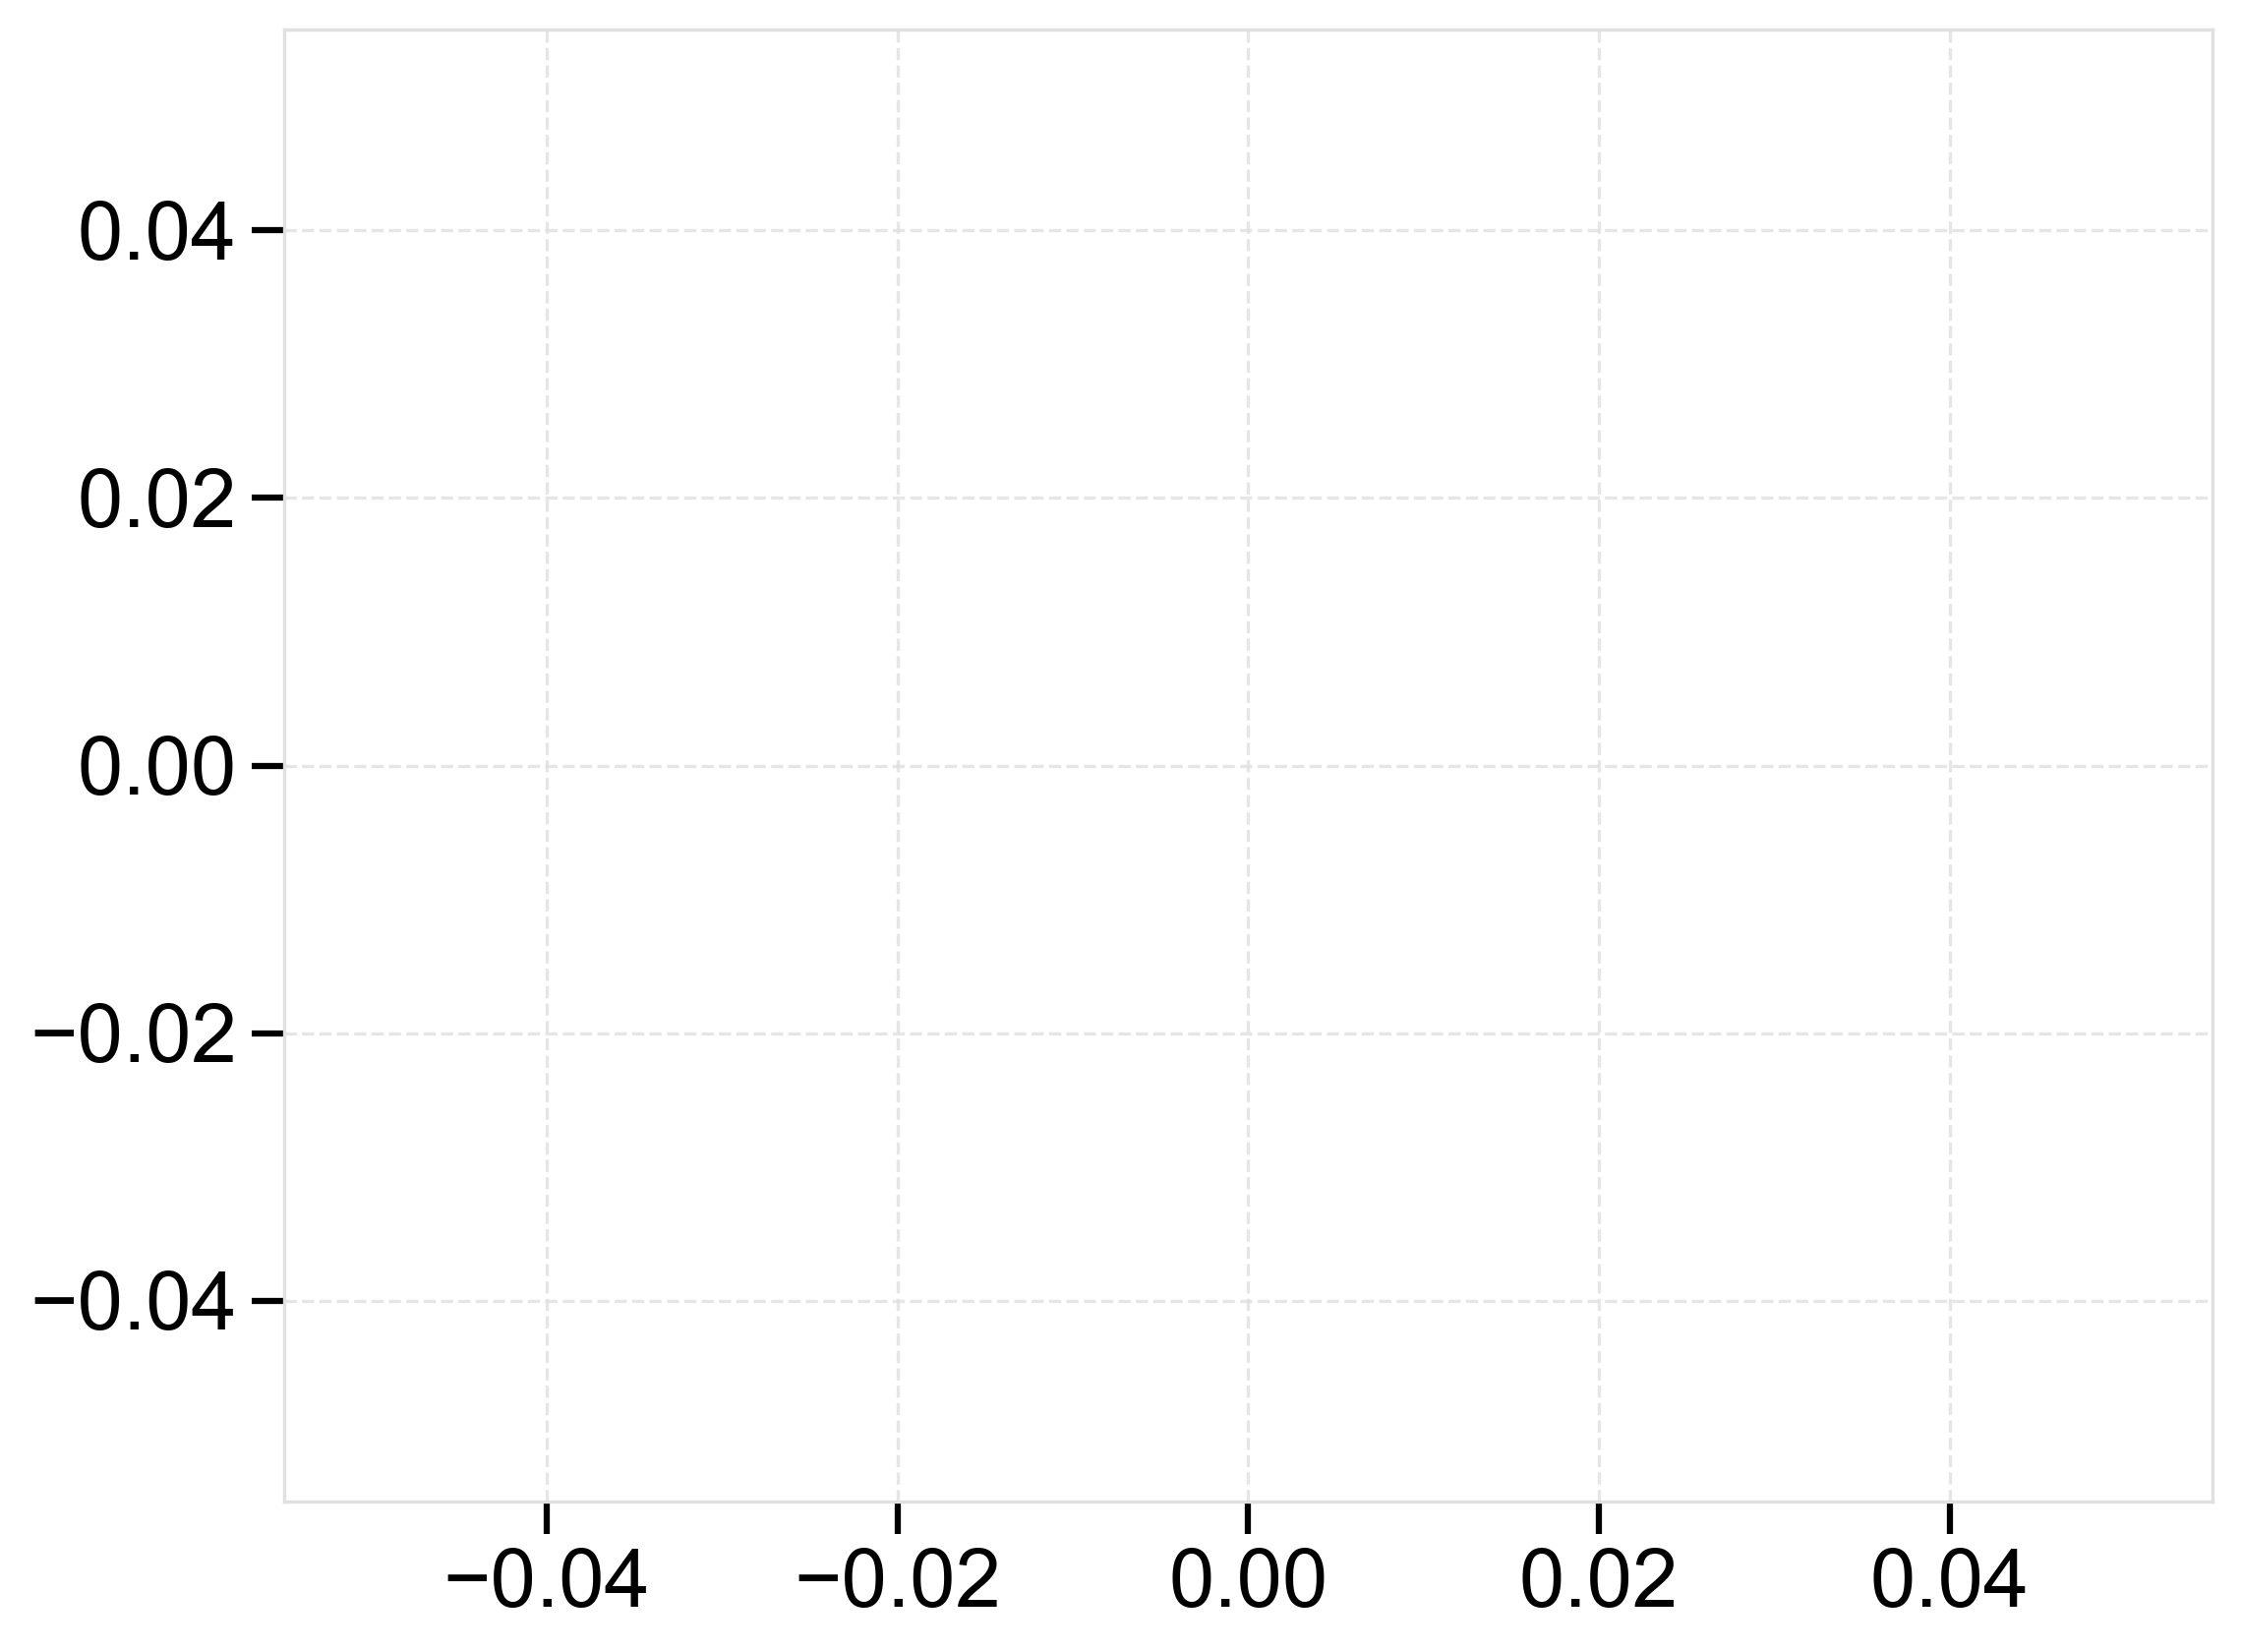

In [15]:
fig, ax = plt.subplots()
ax.errorbar([1], mean_1uM, err_1uM)
ax.errorbar([4], mean_4uM, err_4uM)
ax.errorbar([8], mean_8uM, err_8uM)